# El agua que sostiene los ríos de Colorado tiene 15 años

¿Qué pasa cuando el agua subterránea que alimenta tus ríos es más vieja que tu mascota?

En las cabeceras del río Colorado, las simulaciones muestran que el calentamiento no solo derrite la nieve más rápido — todo apunta a que también está drenando reservas de agua subterránea que tardaron **décadas o siglos** en acumularse. Y cada grado más de temperatura hace que el agua que llega al río sea más vieja.

---

**Paper:** Siirila-Woodburn, E.R. et al. (2026). *Warming and snow loss increase reliance on old groundwater in a Colorado River headwater.* Nature Geoscience.
**DOI:** [10.1038/s41561-026-01945-y](https://doi.org/10.1038/s41561-026-01945-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-10-agua-subterranea-vieja-colorado/notebook.ipynb)

**Video:** [Pendiente]

## ¿Qué midieron?

La cuenca del East River, en las Montañas Rocosas de Colorado (EE.UU.), es una de las cabeceras del río Colorado — el que abastece a 40 millones de personas. Está entre 2.800 y 4.100 metros de altitud, y depende casi por completo de la nieve invernal para recargar sus acuíferos.

Un equipo de Lawrence Berkeley National Lab usó un modelo hidrogeológico de alta resolución (ParFlow-CLM) combinado con rastreo de partículas (EcoSLIM, >48 millones de partículas) para simular 7 años hidrológicos (2015-2021) bajo tres escenarios: temperatura actual, +2,5 °C y +4 °C.

Los datos que vas a ver vienen directamente de los archivos de salida del modelo, publicados en abierto.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CALENTAMIENTO_ESCENARIOS = ['+2,5 °C', '+4,0 °C']
PERIODO = '2015-2021'
CUENCA = 'East River, Upper Colorado River Basin'

COLOR_BASELINE = '#2563EB'    # Azul CaM — escenario actual
COLOR_WARM25 = '#D97706'      # Amber — +2.5°C
COLOR_WARM40 = '#DC2626'      # Rojo — +4.0°C
COLOR_HIST = '#BBBBBB'        # Gris — datos históricos
COLOR_ACCENT = '#059669'      # Emerald — acento

FUENTE = 'Fuente: Siirila-Woodburn et al. (2026), Nat. Geosci. | Datos: NERSC/ESS-DIVE'

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
swe = pd.read_csv('datos/swe_daily.csv')
q_sim = pd.read_csv('datos/streamflow_daily.csv')
gw_age = pd.read_csv('datos/gw_storage_age_mu.csv', index_col=0)
eco = pd.read_csv('datos/ecoslim_source_fractions.csv')
q_hist = pd.read_csv('datos/discharge_annual.csv')

print(f"Datos cargados:")
print(f"  SWE diario: {len(swe):,} registros ({swe['water_year'].nunique()} años × 3 escenarios)")
print(f"  Caudal simulado: {len(q_sim):,} registros")
print(f"  Edad media GW: {len(gw_age)} años × 3 escenarios")
print(f"  Fuentes del caudal: {len(eco)} registros")
print(f"  Caudal histórico USGS: {len(q_hist)} años ({q_hist['water_year'].min()}-{q_hist['water_year'].max()})")

Datos cargados:
  SWE diario: 7,650 registros (7 años × 3 escenarios)
  Caudal simulado: 7,671 registros
  Edad media GW: 7 años × 3 escenarios
  Fuentes del caudal: 21 registros
  Caudal histórico USGS: 114 años (1911-2024)


## Menos nieve, más rápido

¿Cuánta nieve pierde la cuenca con cada grado de calentamiento?

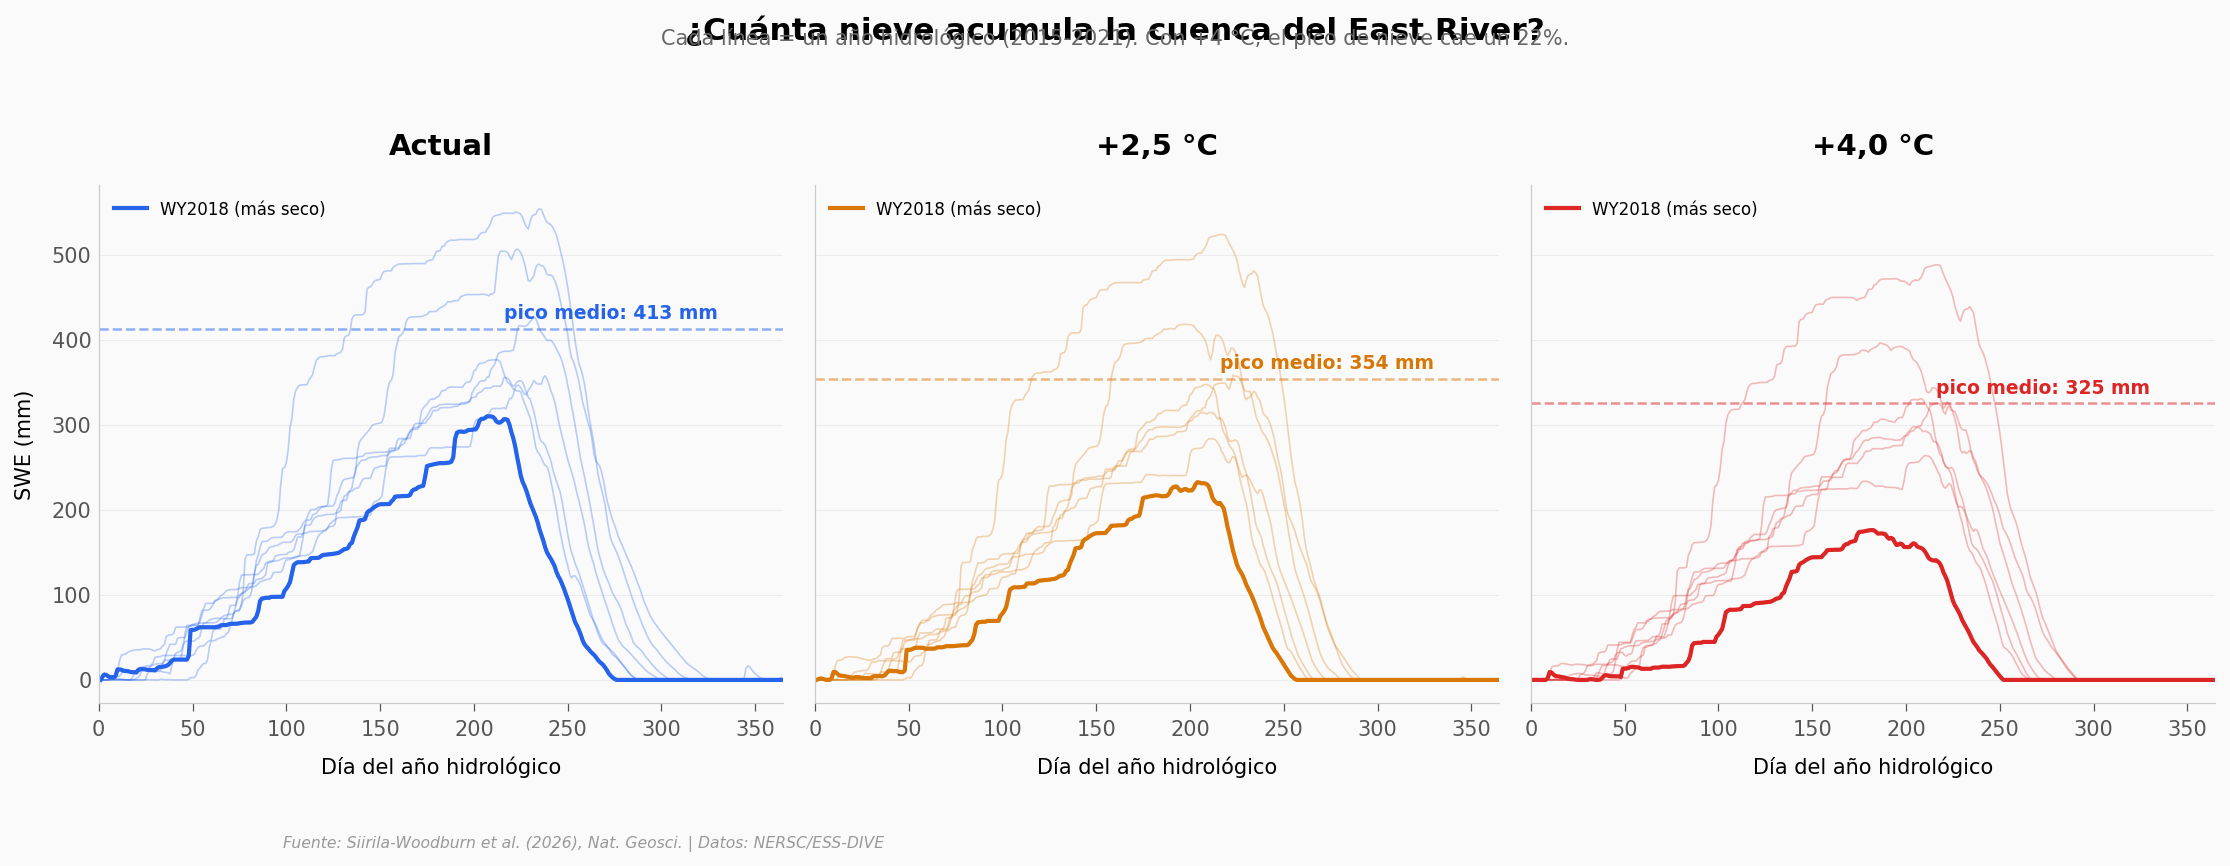

In [2]:
# ── Gráfica hero: Nieve acumulada (SWE) por escenario ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

scenarios = [('baseline', COLOR_BASELINE, 'Actual'),
             ('2.5', COLOR_WARM25, '+2,5 °C'),
             ('4.0', COLOR_WARM40, '+4,0 °C')]

for ax, (sc, color, label) in zip(axes, scenarios):
    for wy in range(2015, 2022):
        sub = swe[(swe['scenario'] == sc) & (swe['water_year'] == wy)]
        alpha = 0.3 if wy != 2018 else 0.8
        lw = 0.8 if wy != 2018 else 1.5
        ax.plot(sub['day_of_wy'], sub['swe_mm'], color=color, alpha=alpha, linewidth=lw)

    # WY2018 highlighted (driest year)
    sub18 = swe[(swe['scenario'] == sc) & (swe['water_year'] == 2018)]
    ax.plot(sub18['day_of_wy'], sub18['swe_mm'], color=color, linewidth=2, label='WY2018 (más seco)')

    # Peak SWE annotation
    peaks = swe[swe['scenario'] == sc].groupby('water_year')['swe_mm'].max()
    mean_peak = peaks.mean()
    ax.axhline(y=mean_peak, color=color, linewidth=1.2, linestyle='--', alpha=0.5)
    ax.text(330, mean_peak + 12, f'pico medio: {mean_peak:.0f} mm',
            fontsize=9, color=color, fontweight='bold', ha='right')

    ax.set_title(label, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Día del año hidrológico', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('SWE (mm)', fontsize=10)
    ax.set_xlim(0, 365)
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('¿Cuánta nieve acumula la cuenca del East River?',
             fontsize=15, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, f'Cada línea = un año hidrológico ({PERIODO}). Con +4 °C, el pico de nieve cae un 22%.',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/swe_escenarios.png', dpi=200, bbox_inches='tight')
plt.show()

## Lectura guiada

El patrón es claro: con cada grado de calentamiento, el pico de nieve baja. En promedio, la cuenca pierde un 14% de su nieve máxima con +2,5 °C y un 21% con +4 °C. Pero lo que más llama la atención es el año más seco (WY2018, línea más gruesa): con +4 °C, su pico de nieve pasa de 310 mm a apenas 176 mm — una reducción del 43%.

Esa nieve es la que recarga el acuífero. Menos nieve → menos recarga → el sistema empieza a consumir agua vieja.

## El agua subterránea envejece

Si la nieve recarga menos el acuífero, ¿qué pasa con la edad del agua almacenada? Veamos.

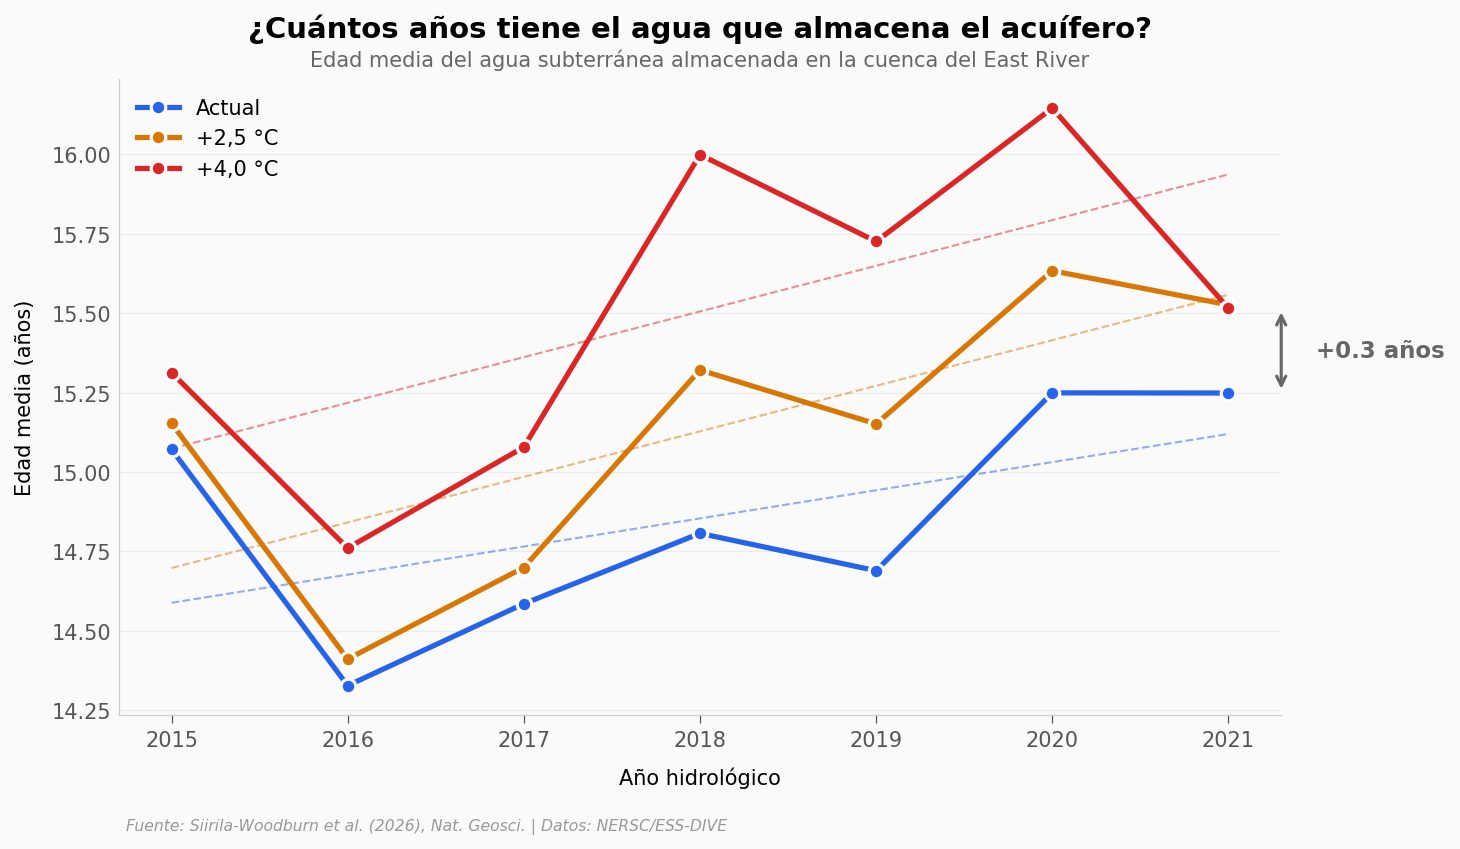

Edad media GW almacenada:
  Actual: 14.85 años (rango 14.33-15.25)
  +2,5 °C: 15.13 años (rango 14.41-15.63)
  +4,0 °C: 15.51 años (rango 14.76-16.15)
  Diferencia actual→+4°C: +0.65 años en promedio


In [3]:
# ── Edad media del agua subterránea por escenario ──
fig, ax = plt.subplots(figsize=(10, 5.5))

years = gw_age.index.astype(int)
colors = {'baseline': COLOR_BASELINE, '2.5': COLOR_WARM25, '4.0': COLOR_WARM40}
labels = {'baseline': 'Actual', '2.5': '+2,5 °C', '4.0': '+4,0 °C'}

for sc in ['baseline', '2.5', '4.0']:
    vals = gw_age[sc].values
    ax.plot(years, vals, 'o-', color=colors[sc], linewidth=2.5, markersize=7,
            markeredgecolor='white', markeredgewidth=1.5, label=labels[sc], zorder=5)
    # Trend line
    slope, intercept, r, p, se = stats.linregress(np.arange(len(vals)), vals)
    trend_y = intercept + slope * np.arange(len(vals))
    ax.plot(years, trend_y, '--', color=colors[sc], linewidth=1, alpha=0.5)

# Annotate the gap
y_base_last = gw_age['baseline'].iloc[-1]
y_40_last = gw_age['4.0'].iloc[-1]
ax.annotate('', xy=(2021.3, y_40_last), xytext=(2021.3, y_base_last),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = y_40_last - y_base_last
ax.text(2021.5, (y_base_last + y_40_last) / 2, f'+{diff:.1f} años',
        fontsize=11, fontweight='bold', color='#666666', va='center')

ax.set_title('¿Cuántos años tiene el agua que almacena el acuífero?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Edad media del agua subterránea almacenada en la cuenca del East River',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año hidrológico', fontsize=10)
ax.set_ylabel('Edad media (años)', fontsize=10)
ax.legend(fontsize=10, loc='upper left')
ax.set_xticks(years)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gw_edad_media.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Edad media GW almacenada:")
for sc, label in labels.items():
    vals = gw_age[sc]
    print(f"  {label}: {vals.mean():.2f} años (rango {vals.min():.2f}-{vals.max():.2f})")
print(f"  Diferencia actual→+4°C: +{gw_age['4.0'].mean() - gw_age['baseline'].mean():.2f} años en promedio")

## Lectura guiada

El agua subterránea almacenada tiene en promedio ~15 años. Pero con +4 °C de calentamiento, esa edad sube: en WY2020 llega a 16,1 años. La tendencia ascendente es más pronunciada en los escenarios de calentamiento.

¿Qué significa? Que el acuífero se recarga cada vez menos con agua *nueva* (de la nieve reciente). El sistema va consumiendo reservas que se infiltraron hace décadas. Es como gastar los ahorros en vez de vivir del ingreso mensual.

Según el paper, la edad del agua que llega a los arroyos como flujo base pasa de ~4 a ~6 años en solo 7 años (escenario actual), y hasta ~8 años con +4 °C. Según el paper, el agua intermedia (1-3 años) declina el doble de rápido que el resto.

## 114 años de caudal: la tendencia ya empezó

Las simulaciones cubren solo 7 años. Pero la estación hidrológica del USGS en Almont tiene **114 años de datos** de caudal medido. ¿Se nota la tendencia?

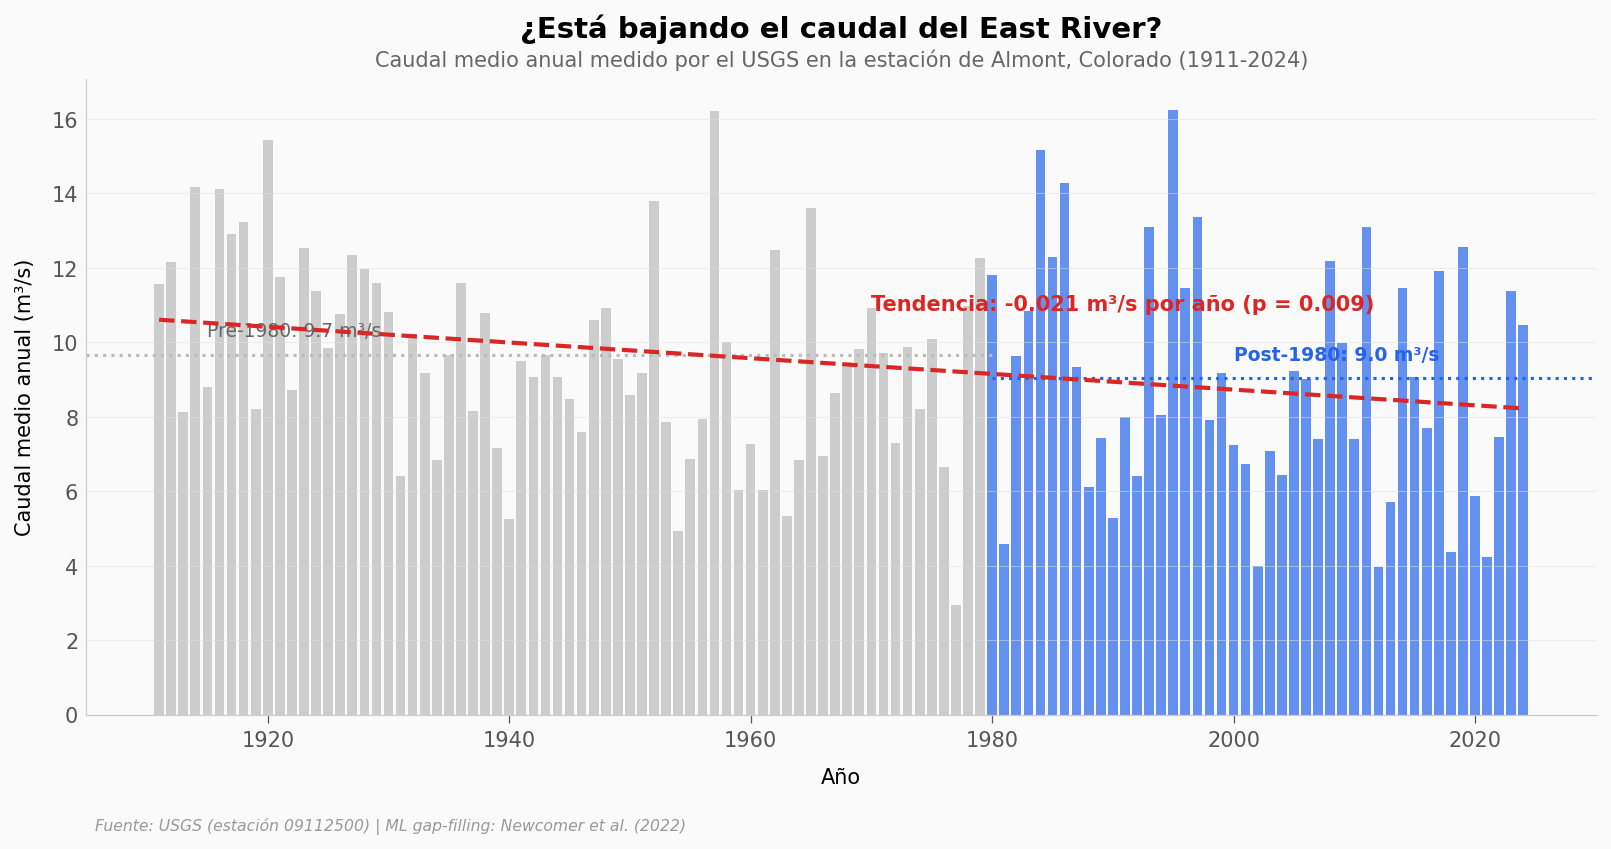

Tendencia: -0.02109 m³/s/año, R² = 0.0595, p = 0.0089
Pre-1980 (n=69): 9.66 m³/s
Post-1980 (n=45): 9.03 m³/s
Cambio: -6.6%


In [4]:
# ── Caudal histórico del East River (USGS, 1911-2024) ──
fig, ax = plt.subplots(figsize=(13, 5.5))

years_hist = q_hist['water_year'].values
q_mean = q_hist['Q_mean_m3s'].values

# Bar chart — color by era
colors_bars = [COLOR_HIST if y < 1980 else COLOR_BASELINE for y in years_hist]
ax.bar(years_hist, q_mean, color=colors_bars, alpha=0.7, width=0.8, edgecolor='none')

# Overall trend line
slope, intercept, r, p, se = stats.linregress(years_hist.astype(float), q_mean)
trend_y = intercept + slope * years_hist
ax.plot(years_hist, trend_y, color=COLOR_WARM40, linewidth=2, linestyle='--', zorder=6)

# Annotate trend
ax.text(1970, intercept + slope * 1970 + 1.5,
        f'Tendencia: {slope:.3f} m³/s por año (p = {p:.3f})',
        fontsize=10, color=COLOR_WARM40, fontweight='bold')

# Pre/post 1980 means
pre_mean = q_mean[years_hist < 1980].mean()
post_mean = q_mean[years_hist >= 1980].mean()
ax.axhline(y=pre_mean, xmin=0, xmax=0.6, color=COLOR_HIST, linewidth=1.5, linestyle=':')
ax.axhline(y=post_mean, xmin=0.6, xmax=1, color=COLOR_BASELINE, linewidth=1.5, linestyle=':')

ax.text(1915, pre_mean + 0.5, f'Pre-1980: {pre_mean:.1f} m³/s', fontsize=9, color='#666666')
ax.text(2000, post_mean + 0.5, f'Post-1980: {post_mean:.1f} m³/s', fontsize=9, color=COLOR_BASELINE, fontweight='bold')

ax.set_title('¿Está bajando el caudal del East River?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Caudal medio anual medido por el USGS en la estación de Almont, Colorado (1911-2024)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Caudal medio anual (m³/s)', fontsize=10)

fig.text(0.13, -0.03, 'Fuente: USGS (estación 09112500) | ML gap-filling: Newcomer et al. (2022)',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/caudal_historico.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Tendencia: {slope:.5f} m³/s/año, R² = {r**2:.4f}, p = {p:.4f}")
print(f"Pre-1980 (n={sum(years_hist < 1980)}): {pre_mean:.2f} m³/s")
print(f"Post-1980 (n={sum(years_hist >= 1980)}): {post_mean:.2f} m³/s")
print(f"Cambio: {(post_mean - pre_mean) / pre_mean * 100:.1f}%")

## Lectura guiada

La tendencia es real: el caudal medio anual ha bajado un 6,6% entre pre-1980 y post-1980 (de 9,7 a 9,0 m³/s, n = 69 y 45 respectivamente). La tendencia lineal es estadísticamente significativa (p = 0,009, Cohen's d = 0,22). Pero la variabilidad interanual es enorme — hay años buenos y años malos.

Lo que las simulaciones revelan es *por qué* baja: no es solo que llueve menos. Es que cuando llueve menos como nieve, el acuífero se recarga menos y el sistema empieza a drenar agua vieja para compensar. Y todo apunta a que esa compensación tiene un límite.

## ¿Qué tan anormal es el caudal reciente?

Pongamos los últimos años en contexto con los 114 años de registro.

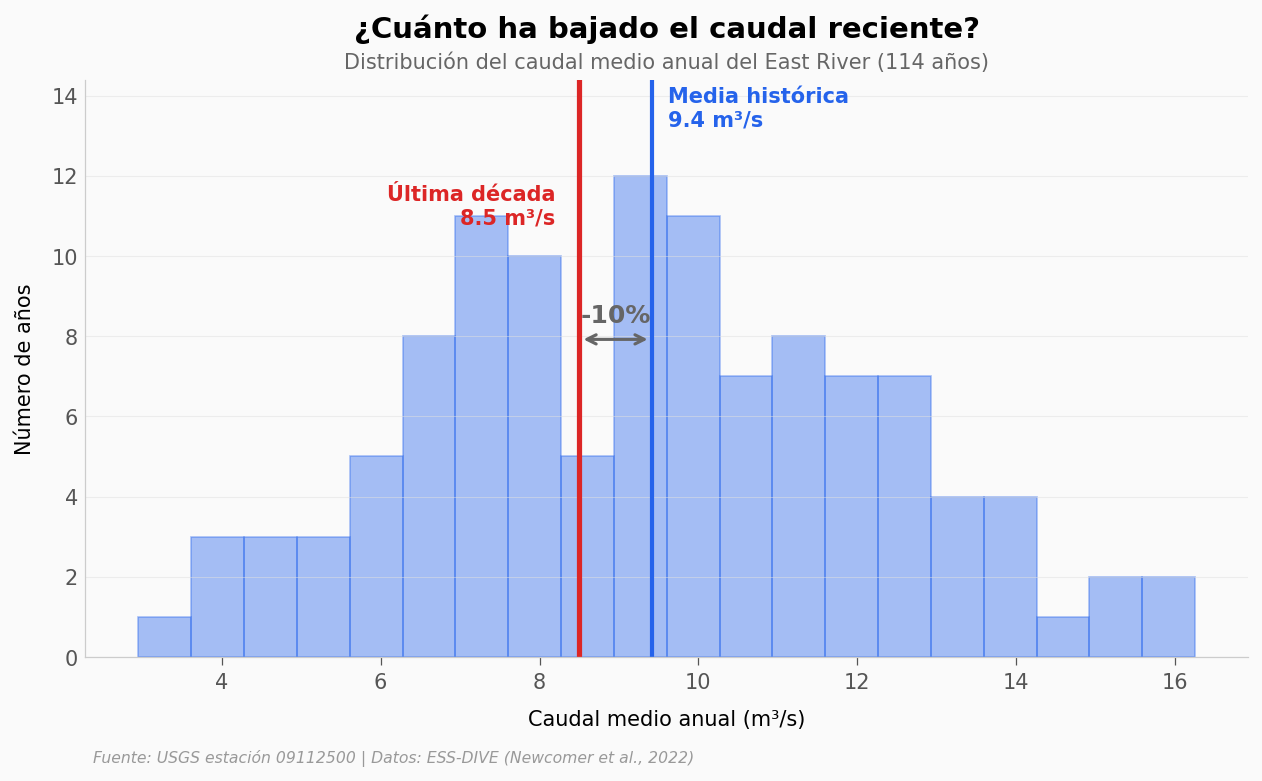

Media histórica (1911-2024): 9.41 m³/s
Media última década (2015-2024): 8.50 m³/s
Diferencia: -9.7%
Años por debajo de la media reciente: 45/114 (39%)


In [5]:
# ── Histograma de anomalía: caudal reciente vs distribución histórica ──
fig, ax = plt.subplots(figsize=(10, 5))

q_all = q_hist['Q_mean_m3s'].values
overall_mean = q_all.mean()

# Histogram
n, bins, patches = ax.hist(q_all, bins=20, color=COLOR_BASELINE, alpha=0.4,
                           edgecolor=COLOR_BASELINE, linewidth=0.8)
y_max = n.max() * 1.2
ax.set_ylim(0, y_max)

# Overall mean
ax.axvline(x=overall_mean, color=COLOR_BASELINE, linewidth=2, linestyle='-')
ax.text(overall_mean + 0.2, y_max * 0.92,
        f'Media histórica\n{overall_mean:.1f} m³/s',
        fontsize=10, color=COLOR_BASELINE, fontweight='bold')

# Recent decade mean (2015-2024)
recent = q_hist.loc[q_hist['water_year'].between(2015, 2024), 'Q_mean_m3s']
recent_mean = recent.mean()
ax.axvline(x=recent_mean, color=COLOR_WARM40, linewidth=2.5)
ax.text(recent_mean - 0.3, y_max * 0.75,
        f'Última década\n{recent_mean:.1f} m³/s',
        fontsize=10, color=COLOR_WARM40, fontweight='bold', ha='right')

# Arrow showing the gap
ax.annotate('', xy=(recent_mean, y_max * 0.55), xytext=(overall_mean, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
pct_diff = (recent_mean - overall_mean) / overall_mean * 100
ax.text((recent_mean + overall_mean) / 2, y_max * 0.58,
        f'{pct_diff:.0f}%', fontsize=12, fontweight='bold', color='#666666', ha='center')

ax.set_title('¿Cuánto ha bajado el caudal reciente?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Distribución del caudal medio anual del East River (114 años)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Caudal medio anual (m³/s)', fontsize=10)
ax.set_ylabel('Número de años', fontsize=10)

fig.text(0.13, -0.03, 'Fuente: USGS estación 09112500 | Datos: ESS-DIVE (Newcomer et al., 2022)',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_caudal.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
print(f"Media histórica (1911-2024): {overall_mean:.2f} m³/s")
print(f"Media última década (2015-2024): {recent_mean:.2f} m³/s")
print(f"Diferencia: {pct_diff:.1f}%")
n_below = sum(q_all < recent_mean)
print(f"Años por debajo de la media reciente: {n_below}/{len(q_all)} ({n_below/len(q_all)*100:.0f}%)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El pico de SWE baja con el calentamiento | ✅ | Reducción media del 21% con +4 °C (rango 12%-43% según el año) |
| La edad del agua subterránea almacenada aumenta con el calentamiento | ✅ | +0,65 años en promedio (baseline→+4 °C). Máxima diferencia en WY2018: +1,2 años |
| El caudal del East River ha bajado en las últimas décadas | ✅ | Tendencia significativa (p = 0,009, n = 114). Pre-1980: 9,7 m³/s (n = 69) → Post-1980: 9,0 m³/s (n = 45), -6,6% (Cohen's d = 0,22) |
| El agua intermedia (1-3 años) declina el doble de rápido | ⚠️ | Reportado por el paper (-12%/década con +4 °C). Nuestros datos (edad media almacenada) son consistentes con el envejecimiento, pero no desglosan por bins de edad |
| El agua vieja (>3 años) compensa la pérdida de agua joven | ⚠️ | El paper reporta un flujo semi-constante (CV = 0,05) de agua vieja. Nuestros datos confirman el envejecimiento pero no tienen la resolución por edad para verificar la compensación directamente |

> **Limitaciones:**
> - Las simulaciones cubren solo 7 años — las tendencias a largo plazo son extrapolaciones
> - Los datos de nieve que usamos son promedios de cuenca (3 bandas de elevación), no el detalle espacial completo
> - Los datos de caudal histórico del USGS son de una estación más abajo que el área modelada (cuenca más amplia)
> - El desglose por edad del agua (joven/intermedia/vieja) viene del rastreo de partículas completo (24 TB), no disponible para descarga — usamos la edad media

## Ahora tú

**1. ¿Cuál es el año más vulnerable?** El año hidrológico 2018 fue el más seco. ¿Cuánto cambia su nieve pico con +4 °C comparado con un año húmedo como 2017? Prueba calcular el ratio `swe_pico_2018 / swe_pico_2017` para cada escenario.

**2. ¿Cómo cambia la fuente del agua?** Los datos de EcoSLIM muestran qué fracción del caudal viene de nieve vs lluvia. Prueba graficar `eco['snow_frac']` por escenario — ¿en cuántos puntos porcentuales baja la nieve?

**3. ¿Hay un umbral de temperatura?** Con los datos de edad media del GW, prueba interpolar a qué calentamiento la edad media superaría los 16 años en promedio. Pista: `np.interp(16, [media_baseline, media_25, media_40], [0, 2.5, 4.0])`.

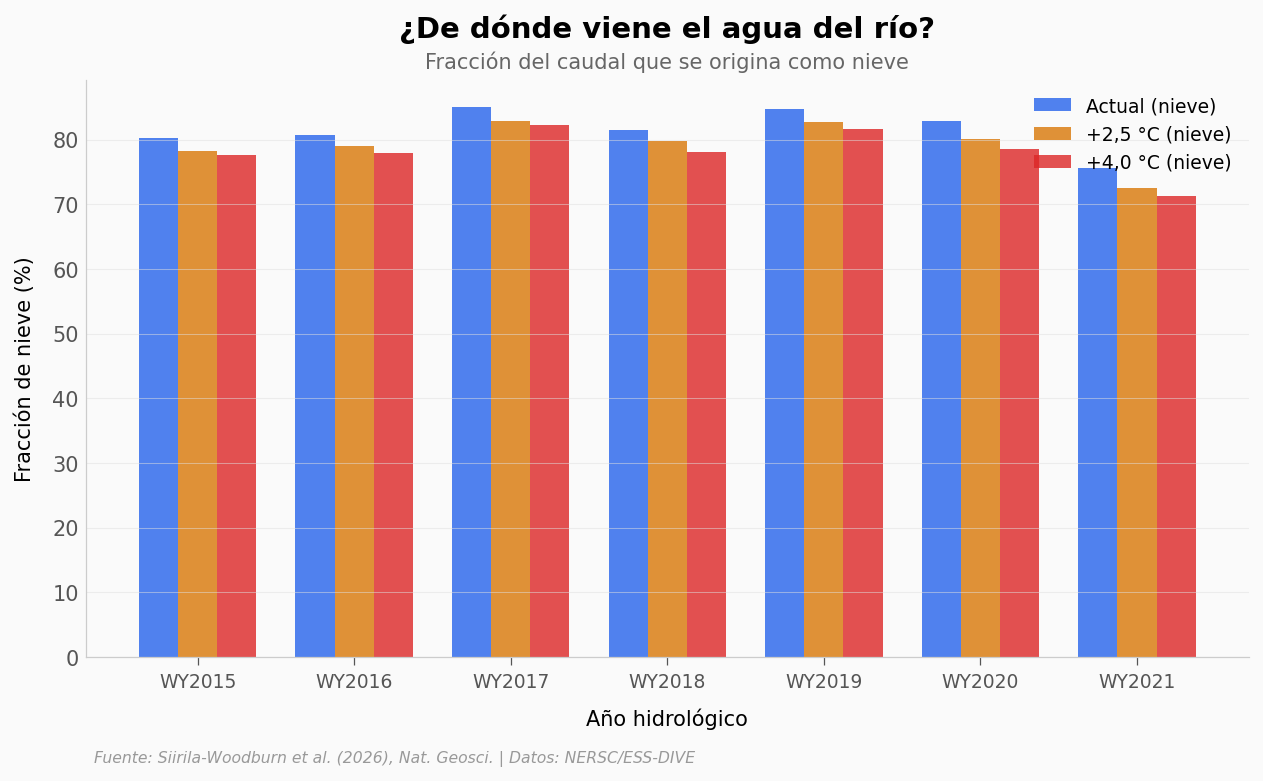

Actual: nieve = 81.6%, lluvia = 13.2%
+2,5 °C: nieve = 79.3%, lluvia = 15.3%
+4,0 °C: nieve = 78.2%, lluvia = 16.1%


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cómo cambia la fuente del caudal con el calentamiento?

fig, ax = plt.subplots(figsize=(10, 5))

width = 0.25
x = np.arange(7)  # 7 water years
wys = list(range(2015, 2022))

for i, (sc, color, label) in enumerate([
    ('baseline', COLOR_BASELINE, 'Actual'),
    ('2.5', COLOR_WARM25, '+2,5 °C'),
    ('4.0', COLOR_WARM40, '+4,0 °C')
]):
    sub = eco[eco['scenario'] == sc].sort_values('water_year')
    ax.bar(x + i * width, sub['snow_frac'] * 100, width,
           color=color, alpha=0.8, label=f'{label} (nieve)')

ax.set_title('¿De dónde viene el agua del río?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Fracción del caudal que se origina como nieve',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año hidrológico', fontsize=10)
ax.set_ylabel('Fracción de nieve (%)', fontsize=10)
ax.set_xticks(x + width)
ax.set_xticklabels([f'WY{y}' for y in wys], fontsize=9)
ax.legend(fontsize=9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/fuentes_caudal.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
for sc, label in [('baseline', 'Actual'), ('2.5', '+2,5 °C'), ('4.0', '+4,0 °C')]:
    sub = eco[eco['scenario'] == sc]
    print(f"{label}: nieve = {sub['snow_frac'].mean()*100:.1f}%, "
          f"lluvia = {sub['rain_frac'].mean()*100:.1f}%")

---

## Créditos

- **Paper:** Siirila-Woodburn, E.R. et al. (2026). Warming and snow loss increase reliance on old groundwater in a Colorado River headwater. *Nature Geoscience*. DOI: [10.1038/s41561-026-01945-y](https://doi.org/10.1038/s41561-026-01945-y)
- **Datos:** [NERSC EcoSLIM Portal](https://portal.nersc.gov/cfs/ecoslim/) + [ESS-DIVE](https://doi.org/10.15485/3013287) + [USGS Streamflow](https://doi.org/10.5066/F7P55KJN)
- **Modelo:** ParFlow-CLM v3.14 + EcoSLIM (particle tracking)
- **Licencia:** Los datos son públicos y se redistribuyen bajo sus licencias originales
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)